In [41]:
import numpy as np
import xarray as xr
import seaborn as sns
import matplotlib.pyplot as plt

In [42]:
true_f = xr.open_dataset("/cluster/scratch/vogtva/data/bruss/stat_one/_dataset_processed.nc")

In [43]:
true = true_f["data"]
true_sub = true[:, -1, 0]

In [44]:
pred_path = "/cluster/scratch/vogtva/out/cno_outputs/merged_data.npz"

In [45]:
loaded = np.load(pred_path)
data = {}
for key in loaded.files:
    p, b, j = map(int, key.split('_'))
    data.setdefault(p, {}).setdefault(b, {})[j] = loaded[key]

In [46]:
pattern = 3
dp = data[pattern]
arrs = []
for b in range(6):
    d = dp[b][pattern-1]
    arrs.append(d)

arr = np.concatenate(arrs, axis=0)[:,0,:,:]

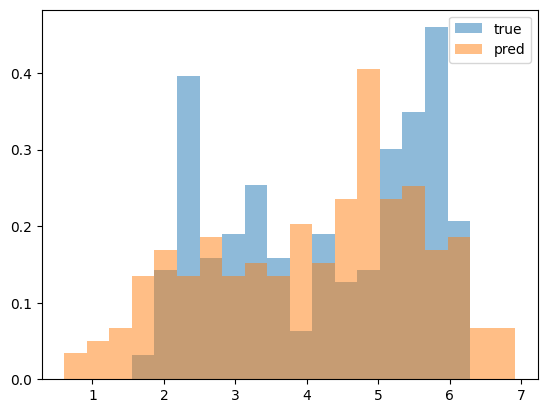

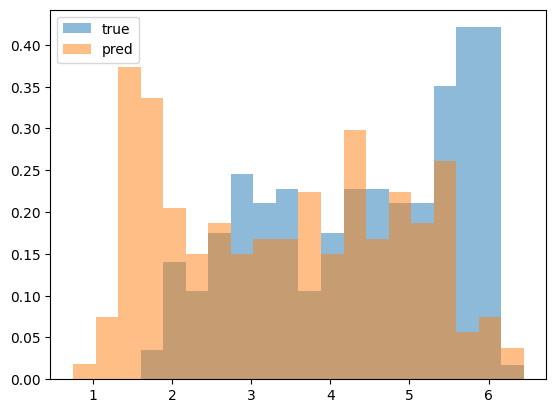

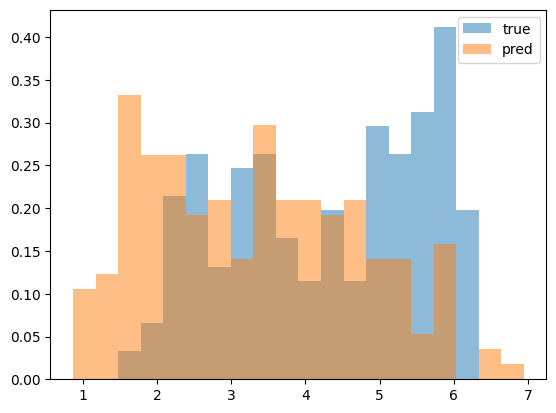

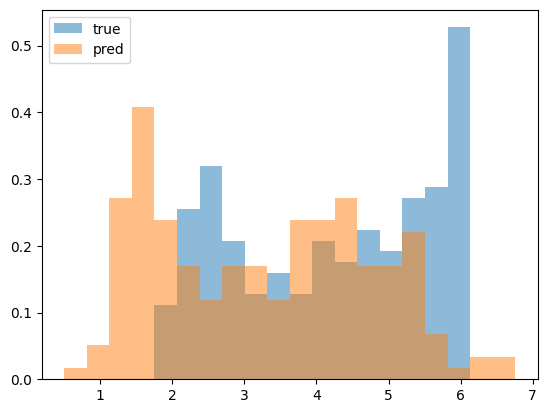

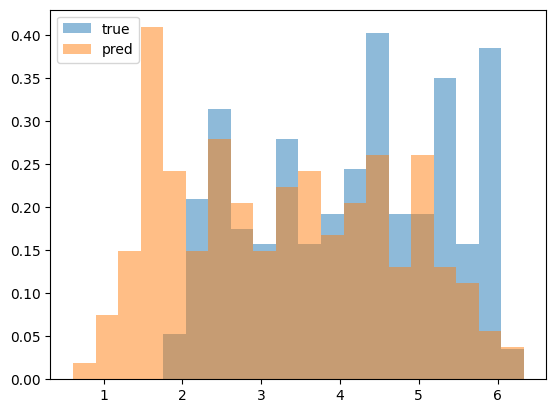

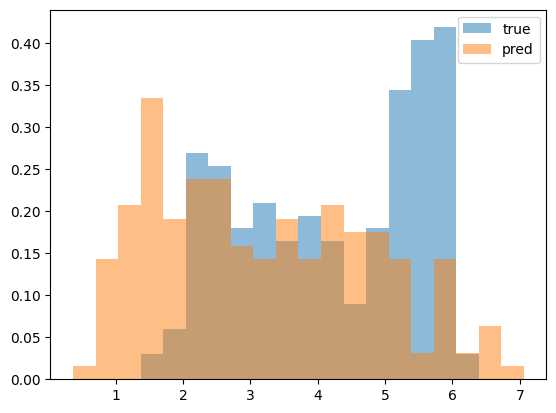

In [47]:
param_set_idx = 0
i0 = 200*param_set_idx
pixels = [(64, i) for i in range(0,128,25)]
for x,y in pixels:
    true_pixel_data= true_sub[i0:i0+200, x, y]
    pred_pixel_data = arr[i0:i0+200, x, y]
    combined = np.concatenate([true_pixel_data, pred_pixel_data])
    bins = np.histogram_bin_edges(combined, bins=20)
    plt.hist(true_pixel_data, bins=bins, alpha=0.5, label="true", density=True)
    plt.hist(pred_pixel_data, bins=bins, alpha=0.5, label="pred", density=True)
    plt.legend()
    plt.show()


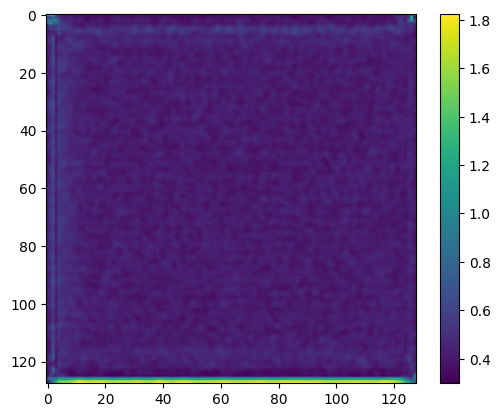

In [48]:
for i0 in range(1):
    true_data= true_sub[i0:i0+188, :, :]
    pred_data = arr[i0:i0+188, :, :]
    diff = np.mean(np.abs(true_data - pred_data) / np.abs(true_data), axis=0)
    plt.imshow(diff)
    plt.colorbar()
    plt.show()